In [ ]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# Query the Mitsuba variant that was automatically selected by Sionna RT.
# There should be no need to adjust it, but if you do, make sure to select
# a variant ending in `*_ad_mono_polarized`.
print(f"Mitsuba variant: {mi.variant()}")

Mitsuba variant: llvm_ad_mono_polarized


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sionna.rt import load_scene

scene = load_scene("/content/drive/MyDrive/sionna rt/test11_gml/citygml_export_4.1_3_38_bui.xml")

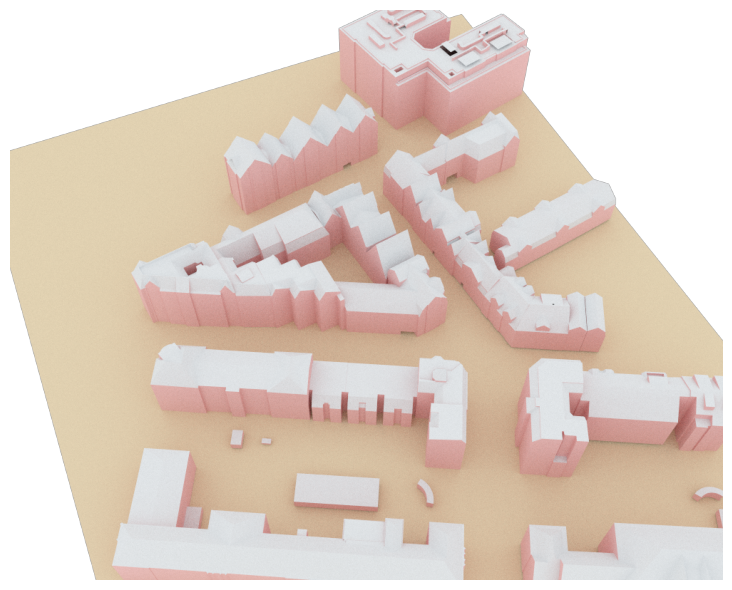

In [ ]:
# Create new camera with different configuration
my_cam = Camera(
    position=[0, 160, 240],
    look_at=[110, 110, 61]
)
# Render scene with new camera*
scene.render(camera=my_cam, resolution=[1000,800], num_samples=128);

In [ ]:
# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V"
)

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V"
)

# Create transmitter
tx = Transmitter(
    name="tx2",
    position=[166, 127, 29],

)

scene.add(tx)

# Create receiver
rx = Receiver(
    name="rx2",
    position=[102, 71, 7.6],

)

scene.add(rx)

# Transmitter points towards receiver
tx.look_at(rx)

In [ ]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

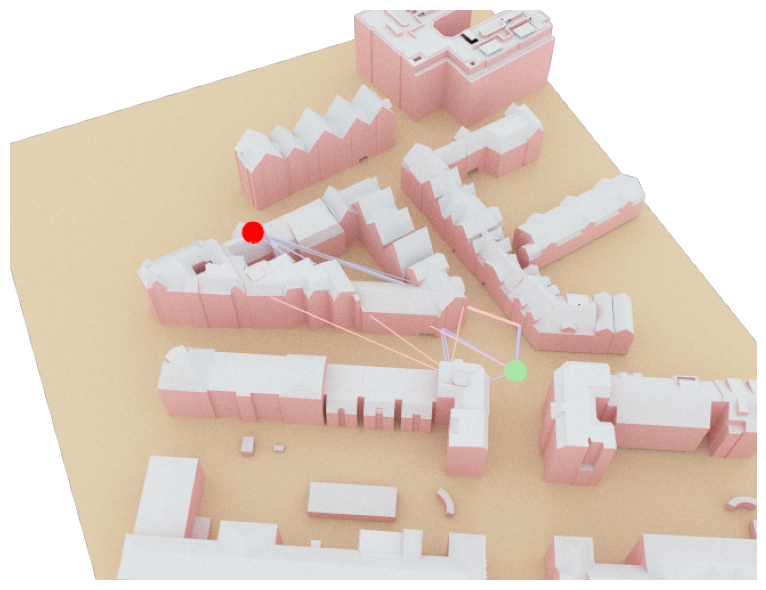

In [ ]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=40);
else:
    scene.preview(paths=paths, clip_at=40);

In [ ]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 1, 1, 1, 8, 1)
Shape of tau:  (1, 1, 1, 1, 8)


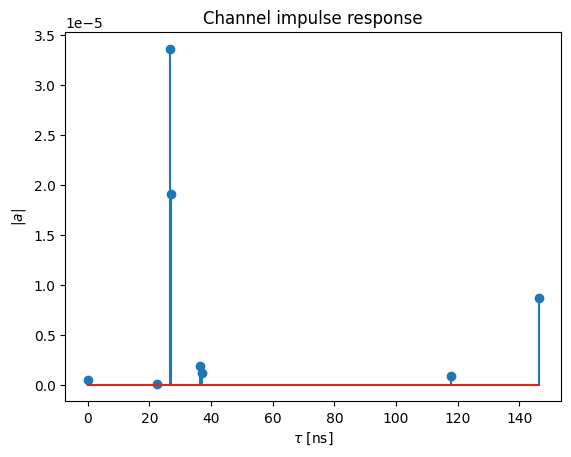

In [ ]:
t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

# And plot the CIR
plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");